In [81]:
!pip install -r requirements.txt

In [82]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             classification_report)
from sklearn.dummy import DummyClassifier
from scipy import stats


sns.set_theme(style="whitegrid", palette="muted")

### Data Loading

In [83]:
def load_data(test=False):
    path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
    df = pd.read_csv(f"{path}/train.csv", sep=';')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

In [84]:
train_df = load_data()

Dataset loaded: 45211 rows, 17 columns.


### Data Inspection

In [85]:
def get_dataset_summary(df):
    """
    Performs basic dataset exploration: types, nulls, and 'unknown' values.
    Reflects the 'inspect before training' goal from Lab 1.
    """
    print(f"--- Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns ---")
    
    # 1. Inspect Data Types (Important for determining encoding strategies)
    print("\n--- Feature Data Types ---")
    print(df.dtypes)
    
    # 2. Check for standard NaNs (Though this dataset typically uses 'unknown')
    print("\n--- Standard Missing Values (NaNs) ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "No standard NaNs found.")
    
    # 3. Check for 'unknown' strings (The dataset's specific way of marking missing data)
    print("\n--- 'Unknown' Value Counts per Column ---")
    found_unknown = False
    for col in df.columns:
        # Check if 'unknown' exists in the column
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            percentage = (unknown_count / len(df)) * 100
            print(f"{col:12}: {unknown_count:>5} values ({percentage:.2f}%)")
            found_unknown = True
            
    if not found_unknown:
        print("No 'unknown' values detected.")

def analyze_outliers(df):
    """
    Identifies outliers using the IQR method from Lab 1.
    Calculates the percentage of data points that fall outside the bounds.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("--- Outlier Analysis (IQR Method) ---")
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100
        
        print(f"{col:10}: {len(outliers):>5} outliers ({percentage:.2f}%)")

In [86]:
get_dataset_summary(train_df)
analyze_outliers(train_df)

--- Dataset Dimensions: 45211 rows, 17 columns ---

--- Feature Data Types ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

--- Standard Missing Values (NaNs) ---
No standard NaNs found.

--- 'Unknown' Value Counts per Column ---
job         :   288 values (0.64%)
education   :  1857 values (4.11%)
contact     : 13020 values (28.80%)
poutcome    : 36959 values (81.75%)
--- Outlier Analysis (IQR Method) ---
age       :   487 outliers (1.08%)
balance   :  4729 outliers (10.46%)
day       :     0 outliers (0.00%)
duration  :  3235 outliers (7.16%)
campaign  :  3064 outliers (6.78%)
pdays     :  8257 outliers (18.26%)
previous  :  8257 outliers (18.26%)


### Visualization

In [87]:
def plot_target_distribution(df):
    """
    Visualizes class imbalance using a Pie Chart.
    As seen in Lab 5, identifying imbalance is critical for choosing metrics.
    """
    plt.figure(figsize=(8, 6))
    counts = df['y'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
    plt.title('Target Variable: Subscription Success Rate')
    plt.show()

def plot_numeric_distributions(df):
    """
    Expanded numeric check. Showing 4 is okay, but adding 'pdays' and 'previous' 
    helps identify patterns in contact frequency.
    """
    numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    # Creating a 3x2 grid to accommodate more features
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col.capitalize()}')
    
    plt.tight_layout()
    plt.show()

def plot_categorical_proportions(df, cat_col):
    """
    FIXED: Removed the '0 Axes' error by passing the ax object correctly.
    This helps identify which segments to target.
    """
    # Create the figure and axis first
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Calculate proportions
    prop_df = pd.crosstab(df[cat_col], df['y'], normalize='index') * 100
    
    # Plot directly onto the axis 'ax'
    prop_df.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    
    ax.set_title(f'Subscription Success Percentage by {cat_col.capitalize()}')
    ax.set_ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', labels=['No', 'Yes'], loc='upper right')
    plt.show()

def plot_correlation_heatmap(df):
    """
    Visualizes relationships between numerical features.
    Helps identify multicollinearity before modeling.
    """
    plt.figure(figsize=(10, 8))
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

def plot_duration_impact(df):
    """
    Uses a boxplot to see the distribution of call duration for each outcome.
    Helps identify if there is a 'minimum time' needed for success.
    """
    plt.figure(figsize=(10, 6))
    # Fix: assign x to hue and set legend=False to suppress the warning
    sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set2', legend=False)
    plt.yscale('log') 
    plt.title('Impact of Call Duration on Subscription (Log Scale)')
    plt.ylabel('Duration (seconds - Log Scale)')
    plt.xlabel('Subscribed?')
    plt.show()

def plot_debt_vs_conversion(df):
    """
    Bivariate analysis of housing/personal loans vs. target.
    Does existing debt prevent clients from investing in deposits?
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Housing Loan vs Target
    prop_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
    prop_housing.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'])
    ax1.set_title('Subscription Rate: Housing Loan Status')
    
    # Personal Loan vs Target
    prop_loan = pd.crosstab(df['loan'], df['y'], normalize='index') * 100
    prop_loan.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Subscription Rate: Personal Loan Status')
    
    plt.show()

def plot_campaign_efficiency(df):
    """
    Visualizes success rate based on the number of contacts in this campaign.
    Identifies the 'sweet spot' for resource allocation.
    """
    plt.figure(figsize=(12, 6))
    # Group by number of contacts and calculate mean 'yes' (1) vs 'no' (0)
    # First, convert 'y' to numeric for calculation
    temp_df = df.copy()
    temp_df['y_numeric'] = temp_df['y'].map({'yes': 1, 'no': 0})
    
    efficiency = temp_df.groupby('campaign')['y_numeric'].mean() * 100
    efficiency.head(10).plot(kind='line', marker='o', color='purple')
    
    plt.title('Conversion Rate % by Number of Contacts (Campaign)')
    plt.xlabel('Number of Contacts during this Campaign')
    plt.ylabel('Success Rate (%)')
    plt.grid(True)
    plt.show()


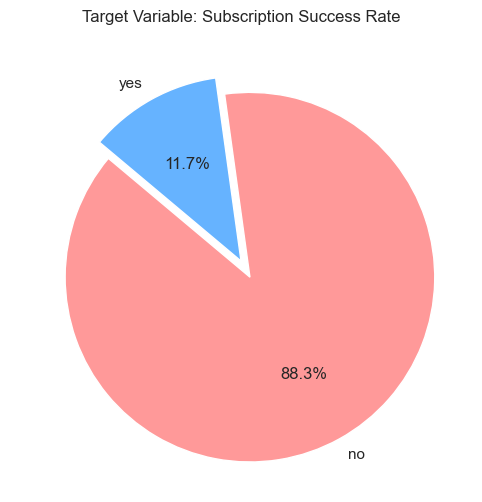

In [88]:
# Class Imbalance (Pie Chart)
plot_target_distribution(train_df)

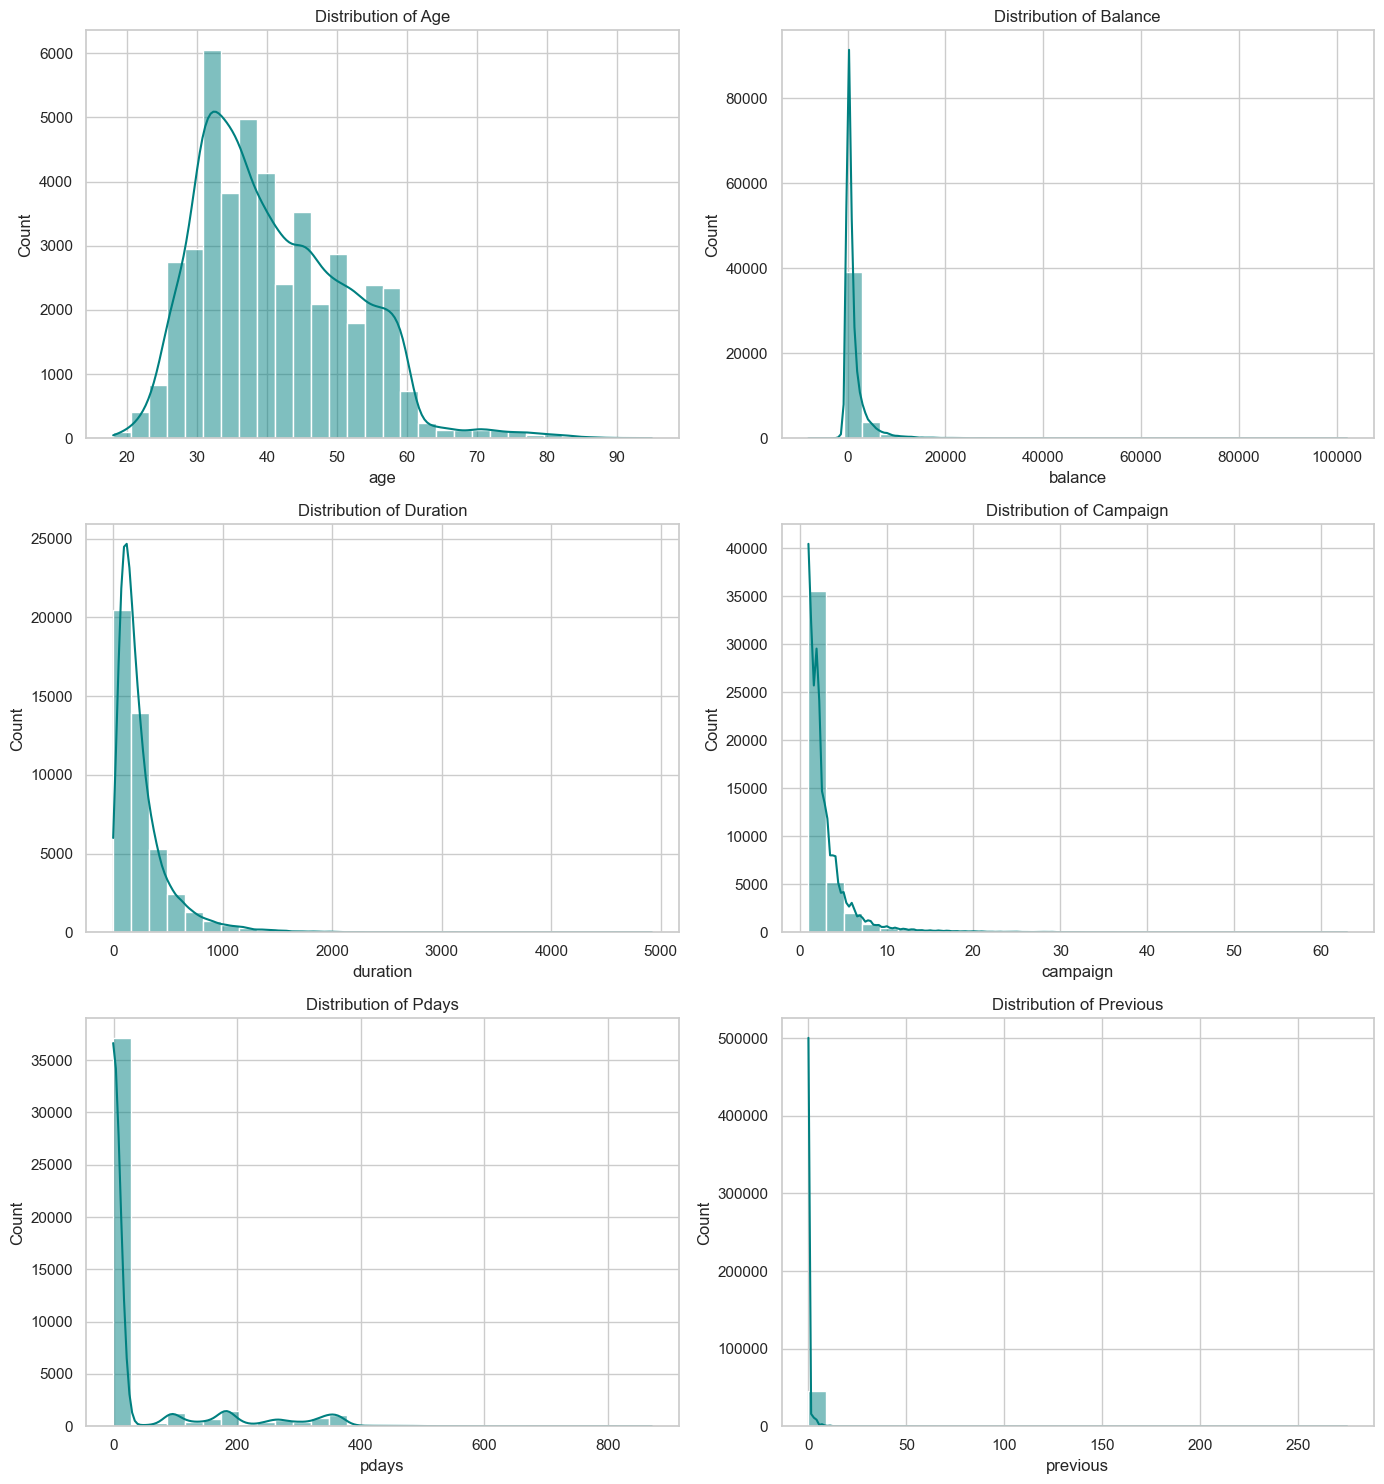

In [89]:
# Numeric Distributions 
plot_numeric_distributions(train_df)

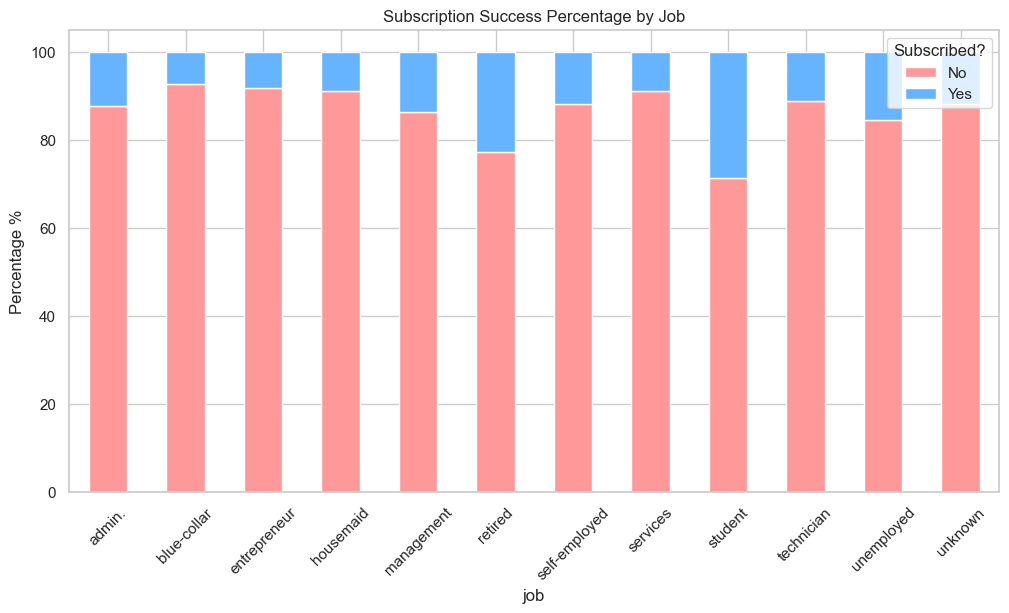

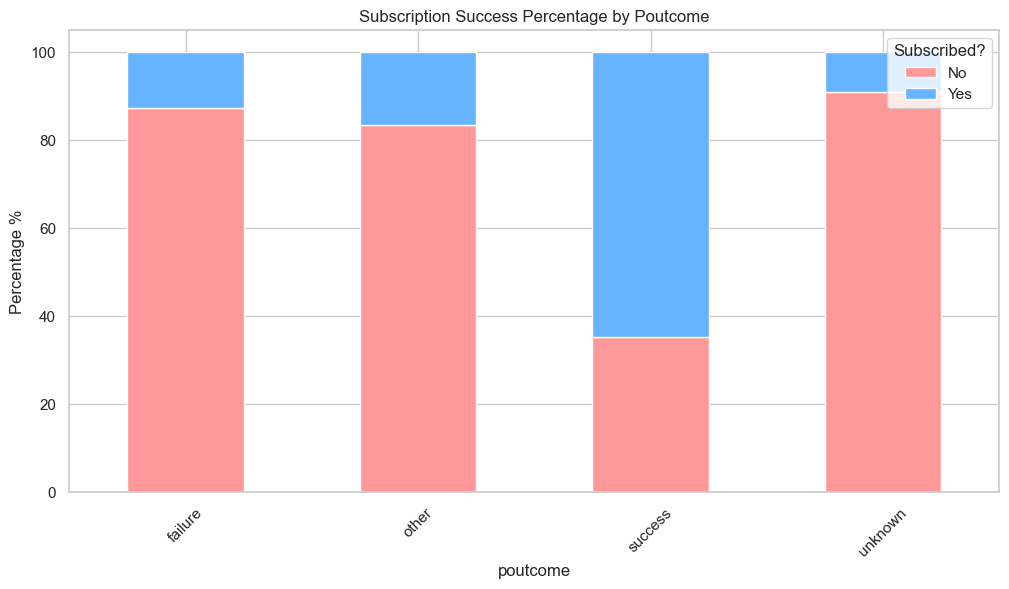

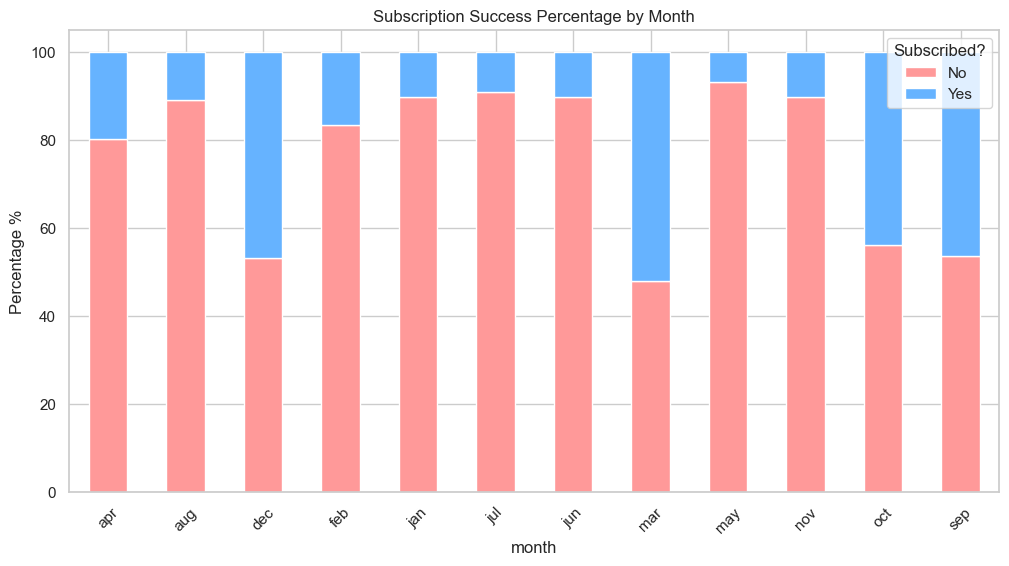

In [90]:
# 3. Categorical Analysis 
plot_categorical_proportions(train_df, 'job')
plot_categorical_proportions(train_df, 'poutcome') 
plot_categorical_proportions(train_df, 'month') 

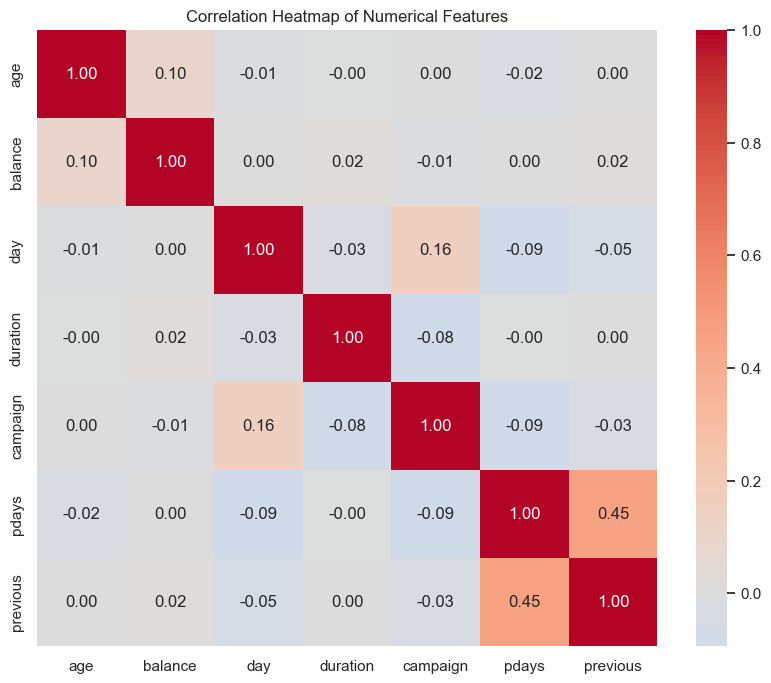

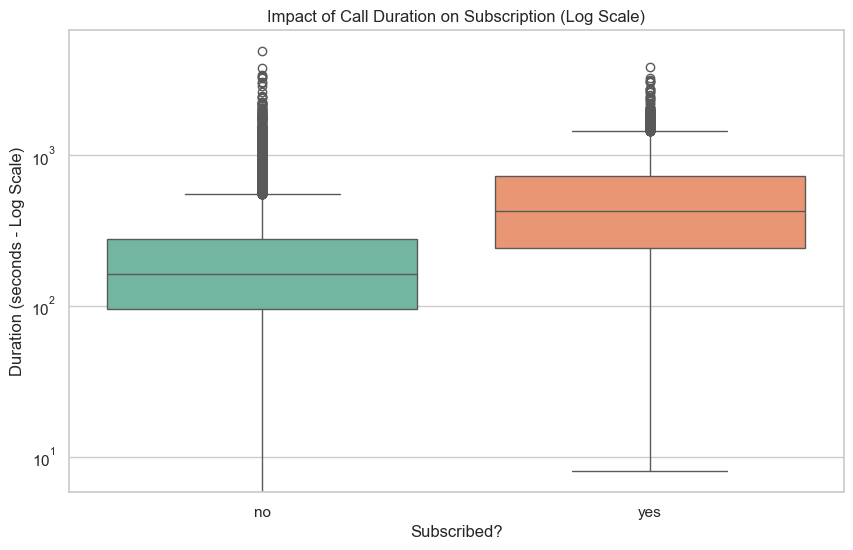

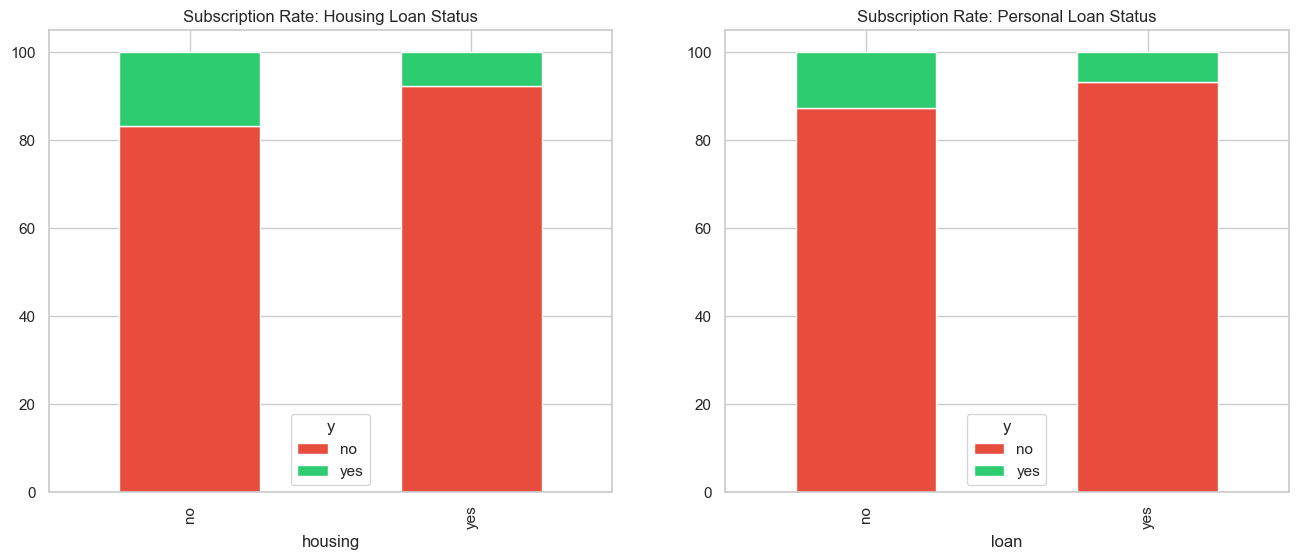

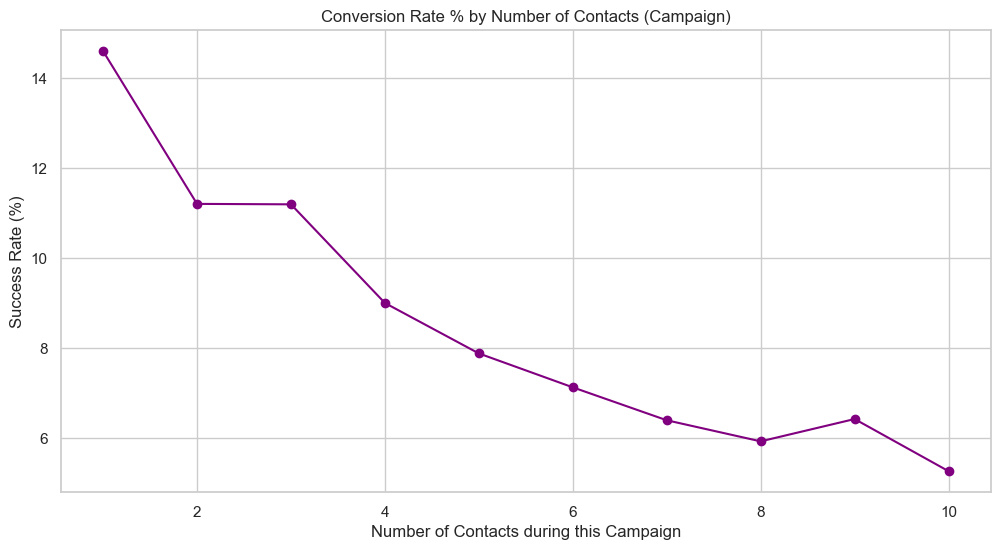

In [91]:
# 4. Advanced Insights 
plot_correlation_heatmap(train_df)
plot_duration_impact(train_df)
plot_debt_vs_conversion(train_df)
plot_campaign_efficiency(train_df)

### Preprocessing

In [92]:
# For both education and month, it matters how close they are, therefore ordinal encoding is appropriate. 
EDUCATION_ORDER = {
    'primary':   1,
    'secondary': 2,
    'tertiary':  3,
}
 
MONTH_ORDER = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
}

# Yes or no is binary, so we can map to 1/0. 
BINARY_COLS = ['default', 'housing', 'loan']
 
# Columns with no natural order → one-hot encoded
OHE_COLS = ['job', 'marital', 'contact', 'poutcome']
 
# Right-skewed numerics (based on visualization of their distributions) that benefit from log compression.
# balance can be negative so it is handled separately
LOG_COLS = ['duration', 'campaign', 'pdays', 'previous']

In [93]:
# Preprocessing structure through pipeline

def preprocess_data(df):
    df = df.copy()


    # Missing Removal, in dataset, missing values are represented as 'unknown' strings. We will replace them with NaN and then impute.
    df.replace('unknown', np.nan, inplace=True)
 
    for col in df.columns:
        if df[col].isna().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
 
    assert df.isna().sum().sum() == 0, "Unexpected NaNs remain after imputation"


    # Ourlier Removal
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'y']
    
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    for col in numeric_cols:
        lower = Q1[col] - 1.5 * IQR[col]
        upper = Q3[col] + 1.5 * IQR[col]
        df[col] = np.clip(df[col], lower, upper)

    # Log transformation for skewed features
    df['pdays'] = df['pdays'].replace(-1, 0)

    for col in LOG_COLS:
            df[col] = np.log1p(df[col])
    
    shift = df['balance'].min()
    if shift < 0:
        df['balance'] = df['balance'] - shift
    df['balance'] = np.log1p(df['balance'])

    # Categorical Encoding
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_ORDER)
   
    # Months are cyclical, therefore they mapped to sin/cos so Dec and Jan are neighbours.
    # Two columns are needed: sin alone maps Jan and Jul to the same value.
    month_num = df['month'].map(MONTH_ORDER)
    df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_num / 12)
    df.drop(columns=['month'], inplace=True)

 
    for col in BINARY_COLS:
        df[col] = df[col].map({'yes': 1, 'no': 0})
 
    #   One-hot encode the remaining categorical features, ensuring we only encode those that are present in the dataset.
    df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)
 
    #   4e. Target
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
 
    # FEATURE ENGINEERING: contact_ratio: how many prior contacts relative to this campaign
    df['contact_ratio'] = df['previous'] / (df['campaign'] + 1)
 
    return df

In [94]:
def split_and_scale(df, target='y', test_size=0.2, random_state=42):
    # Splits into train/test and applies StandardScaler to numeric features.
    # Scaler is fitted only on X_train to prevent data leakage.

    X = df.drop(columns=[target])
    y = df[target]
 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
 
    # Scale only on training data, then apply to test
    scaler = preprocessing.StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )
 
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
 
    return X_train, X_test, y_train, y_test


In [95]:
def cv_classification_metrics(model, X, y, cv):
    scoring = {
        'accuracy': 'accuracy',
        'f1':       'f1',
        'roc_auc':  'roc_auc',
        'aupr':     'average_precision',
    }
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1':       scores['test_f1'].mean(),
        'ROC-AUC':  scores['test_roc_auc'].mean(),
        'AUPR':     scores['test_aupr'].mean(),
        'Fit Time (s)': scores['fit_time'].mean(),
        '_auc_folds': scores['test_roc_auc'],
    }

In [96]:
# Baseline model which always predicts the majority class. All models should outperform this to be considered useful.
def baseline_model(X_train, y_train, cv):    
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    dummy_metrics = cv_classification_metrics(dummy, X_train, y_train, cv)
    for k, v in dummy_metrics.items():
        if not k.startswith('_'):
            print(f"  {k}: {v:.4f}")

    return dummy_metrics

In [97]:
# Logistic regression unregularized 
def logistic_regression_unregularized_model(X_train, y_train, cv):
    lr = LogisticRegression(C=1e6, solver='saga', max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_metrics = cv_classification_metrics(lr, X_train, y_train, cv)
    
    print(f"\nLogistic Regression (unregularized)")
    for k, v in lr_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")
            
    return lr, lr_metrics

In [98]:
# Regularization sweep for logistic regression

def regularization_sweep(X_train, y_train, cv):
    lambdas  = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1, 5, 10, 50, 100]
    C_values = [1/l for l in lambdas]
    
    sweep_results = []
    for C in C_values:
        r = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l2', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        l = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        sweep_results.append({
            'lambda':         1/C,
            'Ridge Accuracy': r['Accuracy'], 'Ridge F1':   r['F1'],
            'Ridge AUC':      r['ROC-AUC'],  'Ridge AUPR': r['AUPR'],
            'Lasso Accuracy': l['Accuracy'], 'Lasso F1':   l['F1'],
            'Lasso AUC':      l['ROC-AUC'],  'Lasso AUPR': l['AUPR'],
        })
    
    sweep_df = pd.DataFrame(sweep_results).set_index('lambda')
    print("\nRegularization sweep (all CV metrics):")
    print(sweep_df.round(4))
    return sweep_df, C_values

In [99]:
# Visualization of regularization effects

def plot_lamba_sweep(sweep_df, lr_metrics):    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plot_cols = [
        ('AUC',      'ROC-AUC'),
        ('AUPR',     'AUPR'),
        ('F1',       'F1'),
        ('Accuracy', 'Accuracy'),
    ]
    for ax, (col_suffix, ylabel) in zip(axes.flatten(), plot_cols):
        ax.plot(sweep_df.index, sweep_df[f'Ridge {col_suffix}'], marker='o', label='Ridge (L2)')
        ax.plot(sweep_df.index, sweep_df[f'Lasso {col_suffix}'], marker='s', label='Lasso (L1)')
        metric_key = 'ROC-AUC' if col_suffix == 'AUC' else ylabel
        ax.axhline(lr_metrics[metric_key], linestyle='--', color='gray', label='Unregularized')
        ax.set_xscale('log')
        ax.set_xlabel('lambda (regularization strength)')
        ax.set_ylabel(f'CV {ylabel}')
        ax.set_title(f'Effect of Regularization on {ylabel}')
        ax.legend(fontsize=8)
    plt.suptitle('Regularization Sweep — Ridge vs Lasso', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


In [100]:
# Best models via LogisticRegressionCV, sklearn selects the best C via internal CV 
def best_regularized_models(X_train, y_train, cv, C_values):
    ridge_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l2', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    ridge_cv.fit(X_train, y_train)
    # Use plain LR at best C to avoid get_params() leaking into metrics
    ridge_best = LogisticRegression(C=ridge_cv.C_[0], penalty='l2', solver='saga',
                                     max_iter=1000, random_state=42)
    ridge_metrics = cv_classification_metrics(ridge_best, X_train, y_train, cv)
    
    print(f"\nBest Ridge  lambda={1/ridge_cv.C_[0]:.4f}")
    for k, v in ridge_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    lasso_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l1', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    lasso_cv.fit(X_train, y_train)
    lasso_best = LogisticRegression(C=lasso_cv.C_[0], penalty='l1', solver='saga',
                                     max_iter=1000, random_state=42)
    lasso_metrics = cv_classification_metrics(lasso_best, X_train, y_train, cv)
    print(f"\nBest Lasso  lambda={1/lasso_cv.C_[0]:.4f}")
    for k, v in lasso_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    return ridge_cv, lasso_cv, ridge_metrics, lasso_metrics

### Ensemble Methods

In [101]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# --- PHASE IV: ENSEMBLE METHODS ---
# --- PHASE IV: ENSEMBLE METHODS (UPGRADED) ---
def train_ensemble_models(X_train, y_train, cv):
    print("\nTraining and Tuning Random Forest...")
    # 1. Define the parameter grid
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_split': [5, 10]
    }
    # 2. Search for the best combination (n_iter=4 keeps it relatively fast)
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'), 
        rf_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    rf_search.fit(X_train, y_train)
    rf_best = rf_search.best_estimator_
    print(f"  Best RF Params: {rf_search.best_params_}")
    
    # 3. Get metrics for the best model
    rf_metrics = cv_classification_metrics(rf_best, X_train, y_train, cv)
    for k, v in rf_metrics.items():
        if not k.startswith('_'): print(f"  CV {k}: {v:.4f}")

    print("\nTraining and Tuning Gradient Boosting...")
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4, 5]
    }
    gb_search = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=42), 
        gb_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    gb_search.fit(X_train, y_train)
    gb_best = gb_search.best_estimator_
    print(f"  Best GB Params: {gb_search.best_params_}")
    
    gb_metrics = cv_classification_metrics(gb_best, X_train, y_train, cv)
    for k, v in gb_metrics.items():
        if not k.startswith('_'): print(f"  CV {k}: {v:.4f}")

    return rf_best, gb_best, rf_metrics, gb_metrics

def plot_ensemble_feature_importance(rf, gb, X_train):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Random Forest Importance
    rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    rf_importances.sort_values().plot(kind='barh', ax=ax1, color='#2ecc71')
    ax1.set_title('Top 15 Features - Random Forest')
    ax1.set_xlabel('Gini Importance')
    
    # Gradient Boosting Importance
    gb_importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    gb_importances.sort_values().plot(kind='barh', ax=ax2, color='#e74c3c')
    ax2.set_title('Top 15 Features - Gradient Boosting')
    ax2.set_xlabel('Friedman MSE Importance')
    
    plt.tight_layout()
    plt.show()

In [102]:
# Coefficient comparison for unregularized vs best Ridge vs best Lasso
def plot_coefficients(lr, ridge_cv, lasso_cv, X_train):
    coef_df = pd.DataFrame({
        'Unregularized': lr.coef_[0],
        'Ridge':         ridge_cv.coef_[0],
        'Lasso':         lasso_cv.coef_[0],
    }, index=X_train.columns)
    
    n_zeroed = (coef_df['Lasso'] == 0).sum()
    print(f"\nLasso zeroed {n_zeroed}/{len(X_train.columns)} features")
    
    # Top 15 features by Ridge magnitude
    top_features = coef_df['Ridge'].abs().nlargest(15).index
    fig, ax = plt.subplots(figsize=(10, 6))
    coef_df.loc[top_features].plot(kind='barh', ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 15 Feature Coefficients — Unregularized vs Ridge vs Lasso')
    ax.set_xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(3, 1, figsize=(20, 4))
    for ax, col in zip(axes, coef_df.columns):
        sns.heatmap(coef_df[[col]].T, annot=False, cmap='coolwarm', center=0,
                    linewidths=0.3, ax=ax, cbar=True)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## Evaluation

In [103]:
# Model comparison 
def model_comparison(dummy_metrics, lr_metrics, ridge_metrics, lasso_metrics, rf_metrics, gb_metrics):
    all_metrics = {
        'Baseline':   dummy_metrics,
        'LR (unreg)': lr_metrics,
        'Ridge':      ridge_metrics,
        'Lasso':      lasso_metrics,
        'Random Forest': rf_metrics,
        'Grad Boost': gb_metrics
    }
    
    comparison_df = pd.DataFrame({
        name: {k: v for k, v in m.items() if not k.startswith('_')}
        for name, m in all_metrics.items()
    }).T
    
    print("\n--- Model Comparison (CV metrics & Training Time) ---")
    print(comparison_df.round(4))
    
    best_name = comparison_df['ROC-AUC'].idxmax()
    print(f"\nSelected model (highest CV AUC): {best_name}")
    sorted_models = comparison_df['ROC-AUC'].sort_values(ascending=False)
    return all_metrics, sorted_models

In [104]:
# Paired t-test on AUC folds between best and runner-up to check if difference is statistically significant across folds, not just due to random chance in this particular split.
def paired_t_test_on_auc(all_metrics, sorted_models):
    best_name_tt = sorted_models.index[0]
    runner_up    = sorted_models.index[1]

    best_folds   = all_metrics[best_name_tt]['_auc_folds']
    runner_folds = all_metrics[runner_up]['_auc_folds']

    t_stat, p_val = stats.ttest_rel(best_folds, runner_folds)
    print(f"\nPaired t-test: {best_name_tt} vs {runner_up}")
    print(f"  t={t_stat:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("  Difference is statistically significant (p < 0.05)")
    else:
        print("  No significant difference (p >= 0.05) — models are comparable")


In [105]:
def final_evaluation(best_name, dummy, lr, ridge_cv, lasso_cv, rf, gb, X_test, y_test):
    best_model = {'Baseline': dummy, 'LR (unreg)': lr,
                'Ridge': ridge_cv, 'Lasso': lasso_cv,
                'Random Forest': rf, 'Grad Boost': gb}[best_name]
    
    y_pred       = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- Test Set Results ({best_name}) ---")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  F1:       {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"  AUPR:     {average_precision_score(y_test, y_pred_proba):.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No', 'Yes'])}")
    
    # ROC and Precision-Recall curves side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1, name=best_name)
    ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
    ax1.set_title('ROC Curve (Test Set)')
    ax1.legend()
    
    PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2, name=best_name)
    ax2.set_title('Precision-Recall Curve / AUPR (Test Set)')
    
    plt.suptitle(f'Final Evaluation — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [106]:
# Stratified CV preserves the ~88/12 class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def complete_pipeline():
    train_df = load_data(test=False)

    # Preprocessing
    clean_df = preprocess_data(train_df)
    X_train, X_test, y_train, y_test = split_and_scale(clean_df)

    # Models Creation (Linear)
    dummy = DummyClassifier(strategy='most_frequent', random_state=42) 
    dummy_metrics = baseline_model(X_train, y_train, cv)
    lr, lr_metrics = logistic_regression_unregularized_model(X_train, y_train, cv)
    sweep_df, C_values = regularization_sweep(X_train, y_train, cv)
    plot_lamba_sweep(sweep_df, lr_metrics)
    ridge_cv, lasso_cv, ridge_metrics, lasso_metrics = best_regularized_models(X_train, y_train, cv, C_values)
    plot_coefficients(lr, ridge_cv, lasso_cv, X_train)

    # Models Creation (Ensembles)
    rf, gb, rf_metrics, gb_metrics = train_ensemble_models(X_train, y_train, cv)
    plot_ensemble_feature_importance(rf, gb, X_train)

    # Model Comparison
    all_metrics, sorted_models = model_comparison(dummy_metrics, lr_metrics, ridge_metrics, lasso_metrics, rf_metrics, gb_metrics)
    paired_t_test_on_auc(all_metrics, sorted_models)

    """ 
    Evaluation
    """
    # Logistic regression
    best_name = sorted_models.index[0]
    final_evaluation(best_name, dummy, lr, ridge_cv, lasso_cv, rf, gb, X_test, y_test)

Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
  Accuracy: 0.8830
  F1: 0.0000
  ROC-AUC: 0.5000
  AUPR: 0.1170
  Fit Time (s): 0.0018


/var/folders/6b/5sb738l16rj_sq65zx2m_wrw0000gn/T/ipykernel_94593/1475372430.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Logistic Regression (unregularized)
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.0657

Regularization sweep (all CV metrics):
          Ridge Accuracy  Ridge F1  Ridge AUC  Ridge AUPR  Lasso Accuracy  \
lambda                                                                      
0.0001            0.8957    0.3739     0.8810      0.5138          0.8957   
0.0010            0.8957    0.3739     0.8810      0.5138          0.8957   
0.0100            0.8957    0.3739     0.8810      0.5138          0.8957   
0.1000            0.8958    0.3739     0.8810      0.5138          0.8957   
0.5000            0.8958    0.3739     0.8810      0.5137          0.8958   
1.0000            0.8958    0.3740     0.8810      0.5138          0.8957   
5.0000            0.8957    0.3726     0.8810      0.5138          0.8958   
10.0000           0.8958    0.3716     0.8810      0.5139          0.8958   
50.0000           0.8958    0.3601     0.8812     

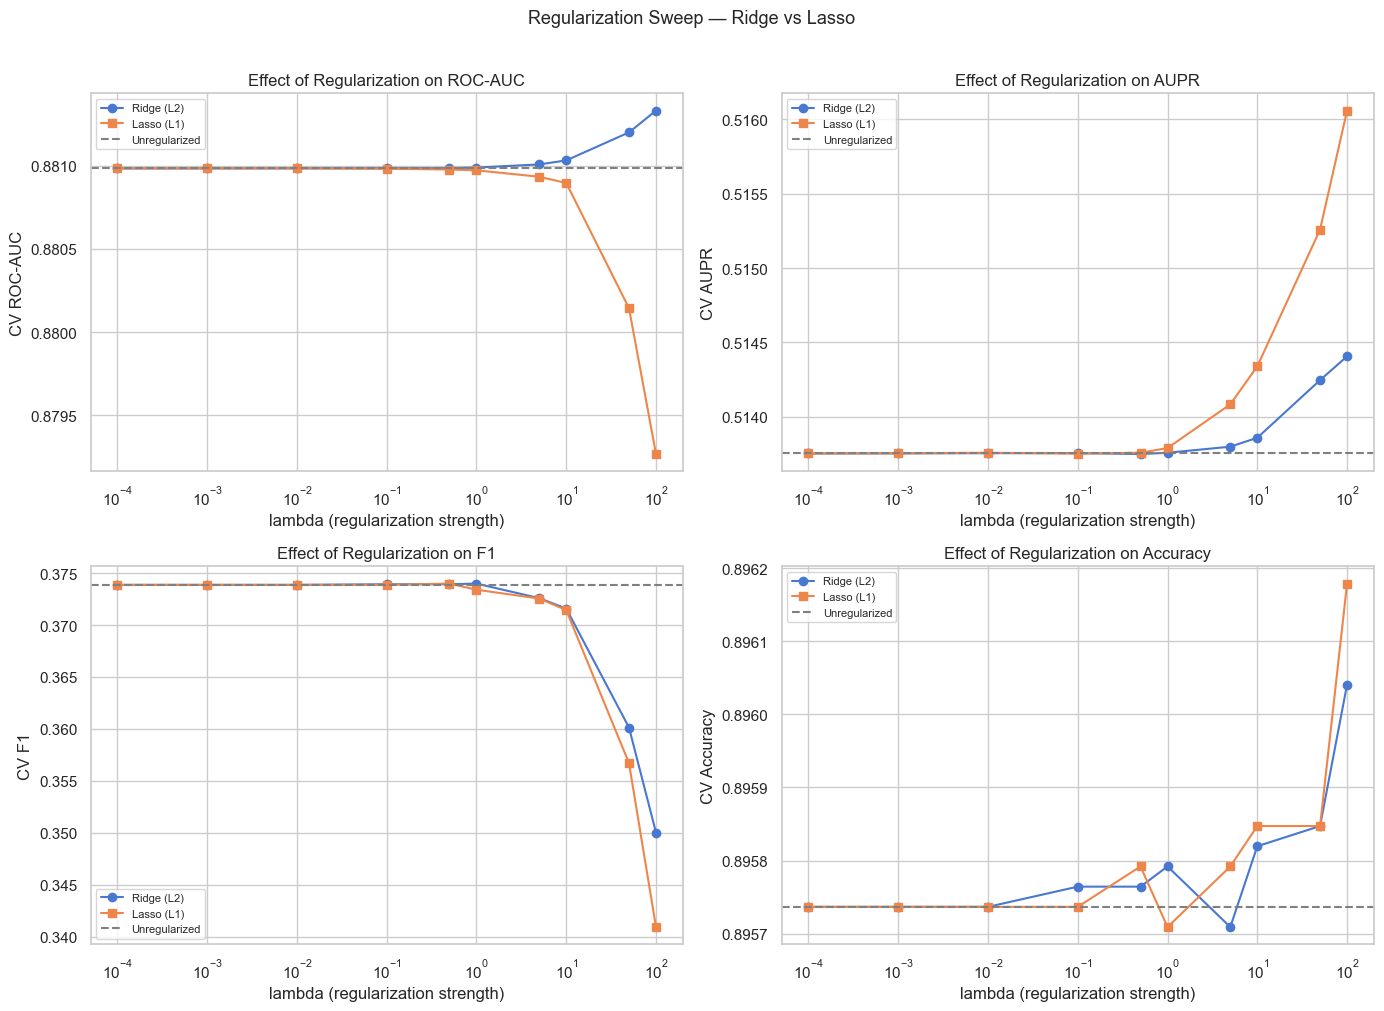


Best Ridge  lambda=100.0000
  CV Accuracy: 0.8960
  CV F1: 0.3500
  CV ROC-AUC: 0.8813
  CV AUPR: 0.5144
  CV Fit Time (s): 0.0669

Best Lasso  lambda=0.0100
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.1071

Lasso zeroed 3/29 features


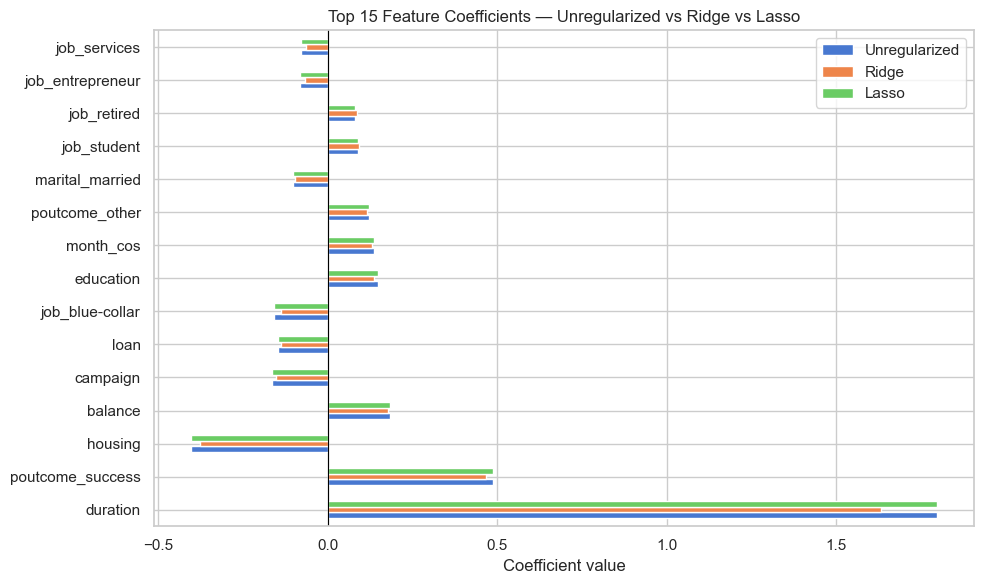

/var/folders/6b/5sb738l16rj_sq65zx2m_wrw0000gn/T/ipykernel_94593/2559837571.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


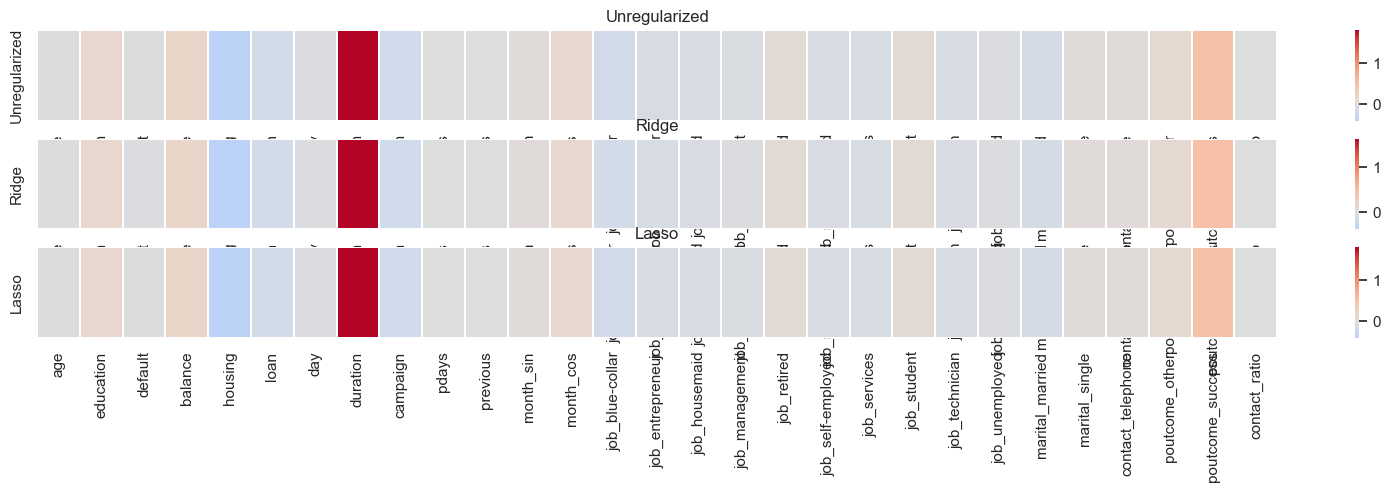


Training and Tuning Random Forest...
  Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}
  CV Accuracy: 0.9003
  CV F1: 0.5340
  CV ROC-AUC: 0.9219
  CV AUPR: 0.5825
  CV Fit Time (s): 3.3729

Training and Tuning Gradient Boosting...
  Best GB Params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
  CV Accuracy: 0.9051
  CV F1: 0.5172
  CV ROC-AUC: 0.9242
  CV AUPR: 0.5951
  CV Fit Time (s): 4.1979


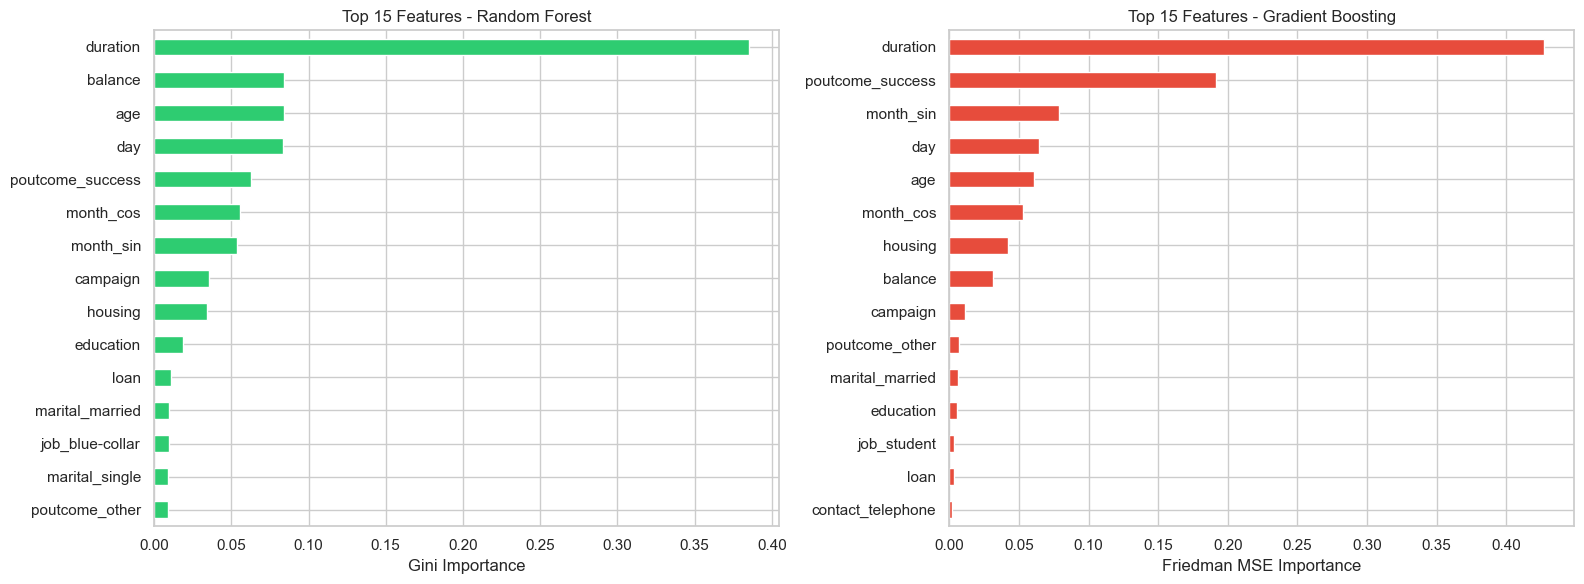


--- Model Comparison (CV metrics & Training Time) ---
               Accuracy      F1  ROC-AUC    AUPR  Fit Time (s)
Baseline         0.8830  0.0000   0.5000  0.1170        0.0018
LR (unreg)       0.8957  0.3739   0.8810  0.5138        0.0657
Ridge            0.8960  0.3500   0.8813  0.5144        0.0669
Lasso            0.8957  0.3739   0.8810  0.5138        0.1071
Random Forest    0.9003  0.5340   0.9219  0.5825        3.3729
Grad Boost       0.9051  0.5172   0.9242  0.5951        4.1979

Selected model (highest CV AUC): Grad Boost

Paired t-test: Grad Boost vs Random Forest
  t=1.6055, p=0.1836
  No significant difference (p >= 0.05) — models are comparable

--- Test Set Results (Grad Boost) ---
  Accuracy: 0.9031
  F1:       0.5084
  ROC-AUC:  0.9217
  AUPR:     0.5918

              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.63      0.43      0.51      1058

    accuracy                           0.90      9

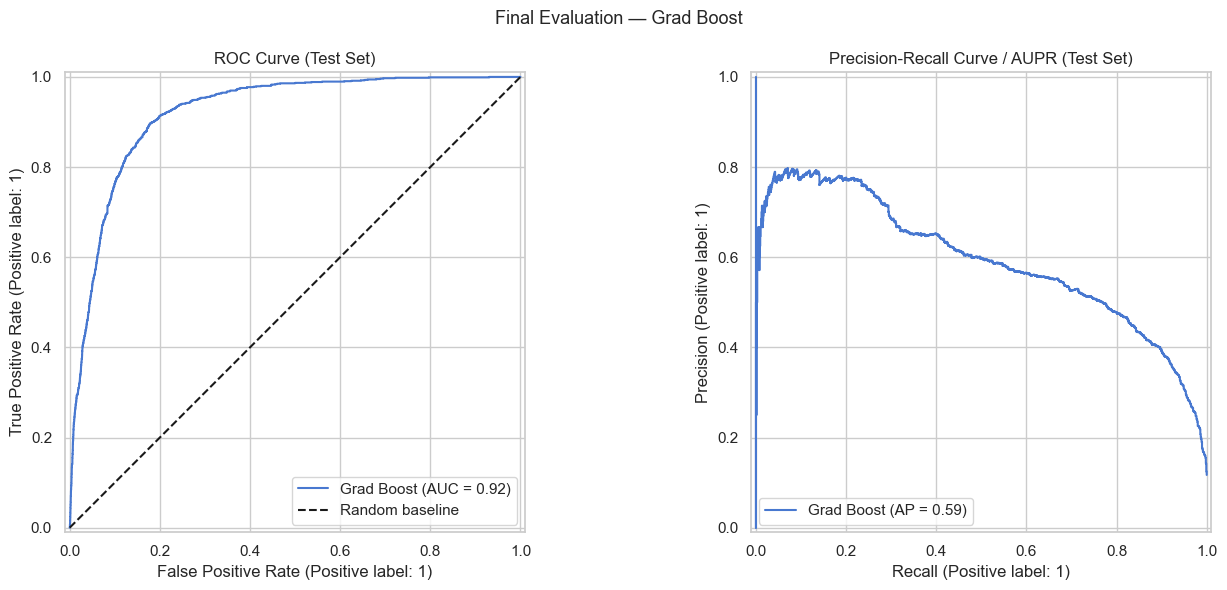

In [107]:
complete_pipeline()